In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

benin = pd.read_csv("../data/benin_clean.csv")
togo = pd.read_csv("../data/togo_clean.csv")
sierra = pd.read_csv("../data/sierraleone_clean.csv")


In [3]:
#STEP 1 — Add a Country Column and Combine Datasets
# Add a 'Country' column to each dataframe
benin["Country"] = "Benin"
togo["Country"] = "Togo"
sierra["Country"] = "Sierra Leone"

# Combine all into one dataframe
df_all = pd.concat([benin, togo, sierra])

# Quick check
print(df_all["Country"].value_counts())
df_all.head()

Country
Benin           525511
Togo            525278
Sierra Leone    522309
Name: count, dtype: int64


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Country
0,2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,Benin
1,2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,Benin
2,2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,Benin
3,2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,Benin
4,2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,Benin


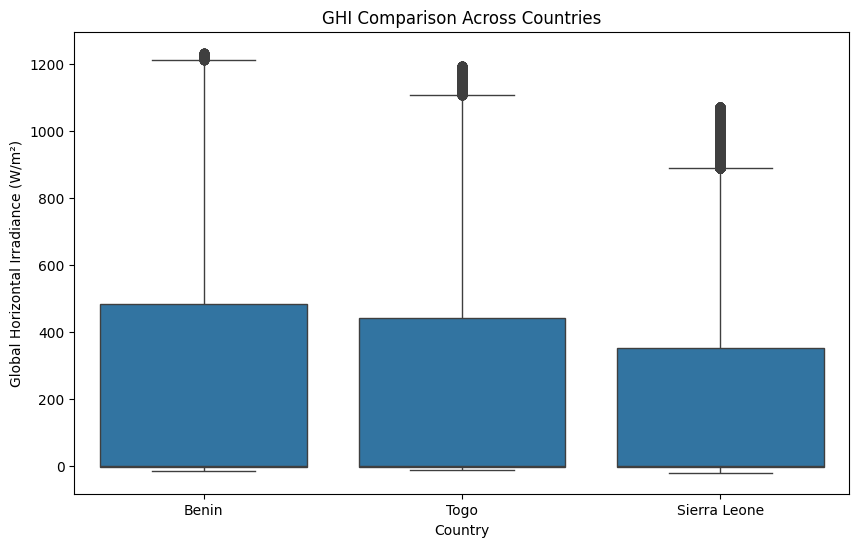

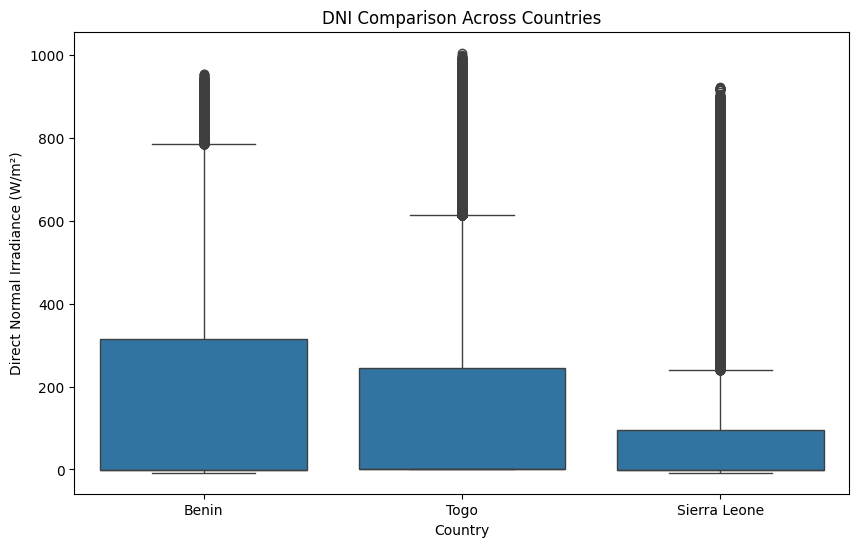

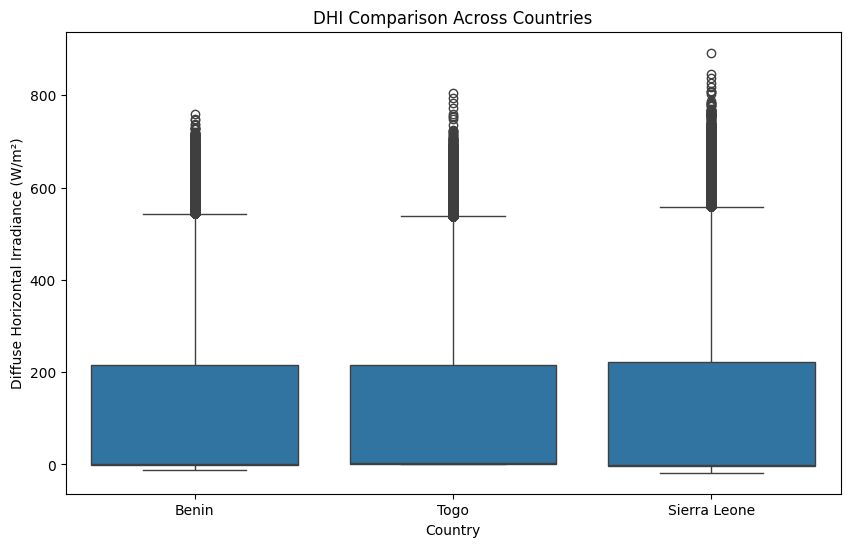

In [4]:
#STEP 2 — Compare Solar Metrics (GHI, DNI, DHI)
plt.figure(figsize=(10,6))
sns.boxplot(x="Country", y="GHI", data=df_all)
plt.title("GHI Comparison Across Countries")
plt.ylabel("Global Horizontal Irradiance (W/m²)")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x="Country", y="DNI", data=df_all)
plt.title("DNI Comparison Across Countries")
plt.ylabel("Direct Normal Irradiance (W/m²)")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x="Country", y="DHI", data=df_all)
plt.title("DHI Comparison Across Countries")
plt.ylabel("Diffuse Horizontal Irradiance (W/m²)")
plt.show()


In [5]:
#STEP 3 — Summary Statistics Table
summary = df_all.groupby("Country")[["GHI", "DNI", "DHI"]].agg(["mean", "median", "std"])
summary

GHI                            DNI                     \
                    mean median         std        mean median         std   
Country                                                                      
Benin         240.383210    1.8  330.881760  167.086020   -0.1  261.614294   
Sierra Leone  195.987618    0.0  289.723363  112.400012   -0.1  213.292034   
Togo          229.932877    2.0  321.648478  150.890963    0.0  250.585171   

                     DHI                     
                    mean median         std  
Country                                      
Benin         115.292156    1.5  158.617632  
Sierra Leone  111.785640   -0.4  157.295766  
Togo          116.209804    2.5  156.264371

In [6]:
#STEP 4 — Statistical Test
from scipy.stats import f_oneway

f_stat, p_val = f_oneway(benin["GHI"], togo["GHI"], sierra["GHI"])
print("ANOVA results on GHI:")
print("F-statistic:", round(f_stat, 3))
print("p-value:", round(p_val, 5))


ANOVA results on GHI:
F-statistic: 2848.92
p-value: 0.0


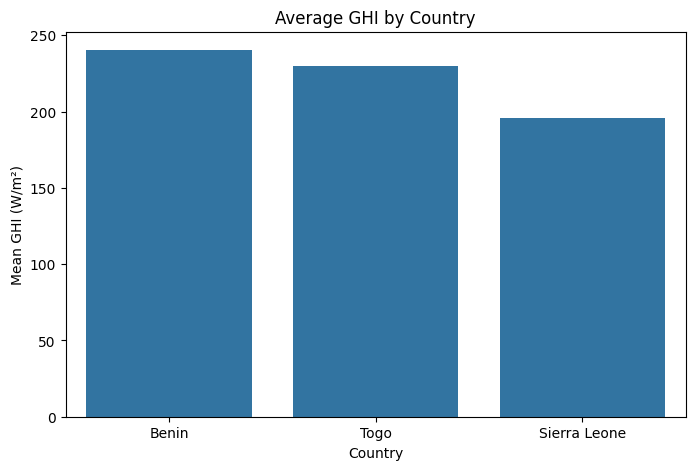

In [7]:
#STEP 5 — Visual Summary (Bar Chart Ranking)
mean_ghi = df_all.groupby("Country")["GHI"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=mean_ghi.index, y=mean_ghi.values)
plt.title("Average GHI by Country")
plt.ylabel("Mean GHI (W/m²)")
plt.xlabel("Country")
plt.show()
